<a href="https://colab.research.google.com/github/vhvaldiviesor/Programacion-para-analitica-descriptiva-y-predictiva/blob/main/Sesion12_Evaluacion_Analisis_Descriptivo_269711.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Evaluación — Análisis Descriptivo de Datos

**Entrega individual**

- **Nombre:** Victor Hugo Valdivieso Rodriguez
- **Matrícula:** 269711

Esta evaluación aplica los cuatro bloques de la Sesión 12 (tendencia central, dispersión, forma, visualización) a un dataset que no se trabajó en clase: **NYC Airbnb 2019**, específicamente la columna `price`.

| | |
|---|---|
| **Tiempo estimado** | 45-55 min |
| **Entrega** | Notebook completo (.ipynb) con todas las celdas ejecutadas, subido a Moodle |
| **Puntaje total** | 100 puntos (ver rúbrica al final) |

Cada actividad tiene su propia pregunta de conclusión — esas respuestas se califican como parte de la actividad correspondiente, no concentradas en la reflexión final. Comenta tu código donde tomes una decisión (por ejemplo, cuántos bins usar en un histograma, o qué columna comparar) — el comentario también forma parte del puntaje.

## Preparación

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url = 'https://raw.githubusercontent.com/pjournal/boun01g-data-mine-r-s/gh-pages/Assignment/AB_NYC_2019.csv'
df = pd.read_csv(url)
df[['name', 'neighbourhood_group', 'room_type', 'price']].head()

,name,neighbourhood_group,room_type,price
0,Clean & quiet apt home by the park,Brooklyn,Private room,149
1,Skylit Midtown Castle,Manhattan,Entire home/apt,225
2,THE VILLAGE OF HARLEM....NEW YORK !,Manhattan,Private room,150
3,Cozy Entire Floor of Brownstone,Brooklyn,Entire home/apt,89
4,Entire Apt: Spacious Studio/Loft by central park,Manhattan,Entire home/apt,80


---
## Actividad 1 — Tendencia central (20 pts)

In [2]:
# 1.1 — Calcula la media, mediana y moda de la columna 'price'.

media_price = df['price'].mean()
mediana_price = df['price'].median()
moda_price = df['price'].mode()[0]  # mode() puede regresar varios valores si hay empate; tomamos el primero

print(f'Media:   {media_price:.2f}')
print(f'Mediana: {mediana_price:.2f}')
print(f'Moda:    {moda_price:.2f}  (aparece {int((df["price"] == moda_price).sum())} veces)')

Media:   152.72
Mediana: 106.00
Moda:    100.00  (aparece 2051 veces)


**1.2 — Conclusión (responde aquí en Markdown):**

¿La media y la mediana de `price` se parecen o divergen mucho? Con base en lo que viste en clase sobre `Income`, ¿qué te sugiere esa divergencia (o esa similitud) sobre la presencia de valores extremos en esta columna?

_Tu respuesta:_

La media (\$152.72) y la mediana (\$106.00) divergen bastante: la media es casi 44% más alta que la mediana (\$46.72 de diferencia). Esta es la misma señal que vimos en clase con `Income` — cuando la media supera claramente a la mediana, significa que hay un grupo de valores extremadamente altos (outliers) que jalan el promedio hacia arriba, mientras que la mediana, al ser el valor de en medio, no se deja afectar por esos extremos.

La sospecha se confirma con el valor máximo de la columna: hay un anuncio en \$10,000 por noche, muy por encima de lo que paga la mayoría (la mitad de los anuncios cuesta \$106 o menos). Con una media así de alejada de la mediana, es de esperar que `price` tenga una distribución con cola larga hacia la derecha (unos pocos alojamientos carísimos entre miles de alojamientos económicos), en vez de una distribución simétrica.

---
## Actividad 2 — Dispersión (20 pts)

In [3]:
# 2.1 — Calcula el rango, la varianza, la desviación estándar y el IQR (Q1, Q3, IQR) de 'price'.

rango_price = df['price'].max() - df['price'].min()
varianza_price = df['price'].var()
std_price = df['price'].std()
q1_price = df['price'].quantile(0.25)
q3_price = df['price'].quantile(0.75)
iqr_price = q3_price - q1_price

print(f'Mínimo: {df["price"].min():.2f}   Máximo: {df["price"].max():.2f}')
print(f'Rango:              {rango_price:.2f}')
print(f'Varianza:           {varianza_price:.2f}')
print(f'Desviación estándar: {std_price:.2f}')
print(f'Q1: {q1_price:.2f}   Q3: {q3_price:.2f}   IQR: {iqr_price:.2f}')

Mínimo: 0.00   Máximo: 10000.00
Rango:              10000.00
Varianza:           57674.03
Desviación estándar: 240.15
Q1: 69.00   Q3: 175.00   IQR: 106.00


**2.2 — Conclusión (responde aquí en Markdown):**

Compara el rango contra el IQR de `price`. ¿Cuál de los dos te parece más representativo de la dispersión "típica" de los precios, y por qué? (revisa el valor máximo de la columna antes de responder)

_Tu respuesta:_

El rango de `price` es \$10,000 (de \$0 a \$10,000), mientras que el IQR es apenas \$106 (de \$69 a \$175). La diferencia entre ambos es enorme: el rango depende únicamente de los dos valores más extremos de todo el dataset (el mínimo y el máximo), así que basta con que exista un solo anuncio atípico de \$10,000 para disparar el rango, aunque ese precio no represente a nadie más. El IQR, en cambio, describe dónde está el 50% central de los datos, ignorando ese 25% más bajo y ese 25% más alto donde se esconden los extremos.

El IQR me parece mucho más representativo de la dispersión "típica": nos dice que la mitad de los alojamientos de Nueva York cuestan entre \$69 y \$175 por noche, un rango de precios creíble y consistente con lo que uno esperaría pagar por un Airbnb. El rango de \$10,000, en cambio, no describe la experiencia típica de nadie — solo confirma que existe al menos un valor extremo, información que ya habíamos anticipado en la Actividad 1 al ver que la media superaba tanto a la mediana.

---
## Actividad 3 — Forma (20 pts)

In [4]:
# 3.1 — Calcula la asimetría (skew) y la curtosis (kurt) de 'price'.

asimetria_price = df['price'].skew()
curtosis_price = df['price'].kurt()

print(f'Asimetría (skew): {asimetria_price:.2f}')
print(f'Curtosis (kurt):  {curtosis_price:.2f}')

Asimetría (skew): 19.12
Curtosis (kurt):  585.67


**3.2 — Conclusión (responde aquí en Markdown):**

Compara estos valores con los de `Income` que viste en clase (asimetría 6.76, curtosis 159.6 con el outlier incluido). ¿Cómo se comparan los de `price`? ¿Qué relación esperarías entre estos valores y lo que vas a encontrar en la próxima etapa del curso (Datos Atípicos)?

_Tu respuesta:_

Los valores de `price` son todavía más extremos que los de `Income` en clase: la asimetría de `price` es de aproximadamente 19.1, casi 3 veces la de `Income` (6.76); y la curtosis de `price` es de aproximadamente 585.7, más de 3.6 veces la de `Income` (159.6). Ambos valores son positivos y muy por encima de lo que se consideraría una distribución razonablemente simétrica (asimetría cercana a 0) o mesocúrtica (curtosis cercana a 0 en el exceso de curtosis de pandas) — una asimetría de casi 19 indica una cola derecha extremadamente larga y pesada, y una curtosis de casi 586 indica una concentración de valores muy apretada alrededor del centro con muy pocos casos, pero extremadamente alejados, en las colas.

Esto me indica que `price` tiene una cantidad de outliers relativamente mayor (o al menos más extremos en magnitud) que `Income`, y anticipa exactamente lo que se va a formalizar en la etapa de Datos Atípicos del curso: cuando lleguemos a calcular los límites de Tukey (Q3 + 1.5×IQR) sobre `price`, espero que un número considerable de anuncios queden marcados como atípicos, dado que ya vimos en la Actividad 2 que el IQR es de solo \$106 mientras el máximo llega a \$10,000 — cualquier alojamiento por encima de unos \$334 (Q3 + 1.5×IQR ≈ 175 + 1.5×106) probablemente ya se clasificaría como atípico bajo ese criterio.

---
## Actividad 4 — Visualización (30 pts)

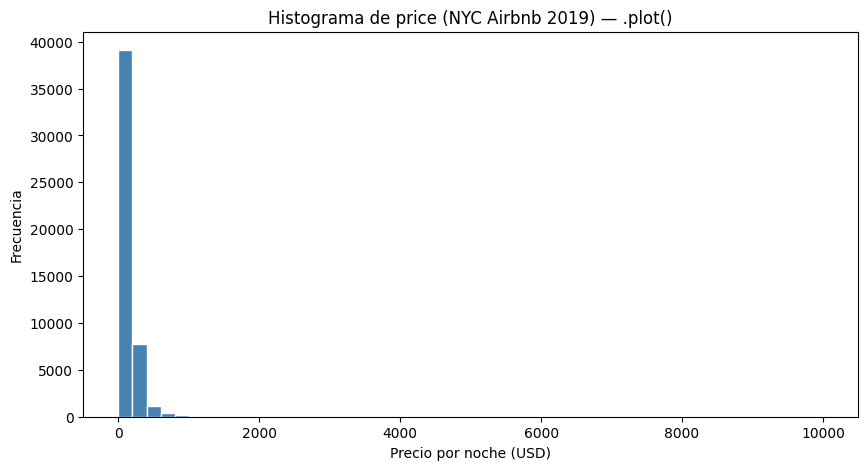

In [5]:
# 4.1 — Construye un histograma de 'price' con .plot(kind='hist').
# Elige un número de bins que te parezca razonable y comenta por qué lo elegiste.

# Con un rango de 0 a 10,000 pero con el 75% de los datos por debajo de $175 (Q3, Actividad 2),
# usamos 50 bins (~$200 de ancho cada uno) como punto de partida razonable para un histograma
# sobre el rango completo -- ni tan pocos que oculten la forma, ni tantos que generen bins
# vacíos en la cola. A propósito NO recortamos el eje x: dejar ver el rango completo hasta
# $10,000 es lo que hace evidente, de forma visual, la asimetría que calculamos en la Actividad 3.
ax = df['price'].plot(kind='hist', bins=50, figsize=(10, 5), color='steelblue', edgecolor='white')
ax.set_title('Histograma de price (NYC Airbnb 2019) — .plot()')
ax.set_xlabel('Precio por noche (USD)')
ax.set_ylabel('Frecuencia')
plt.show()

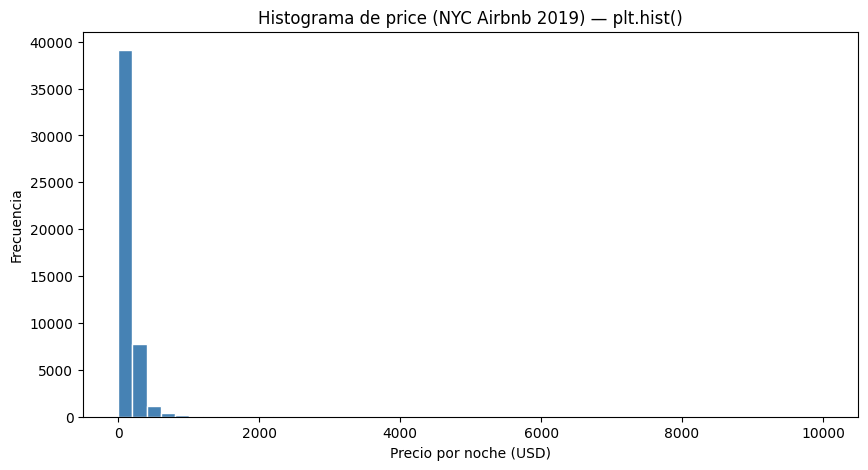

In [6]:
# 4.2 — Construye el mismo histograma con matplotlib.pyplot directamente (plt.hist()),
# agregando título y etiquetas en los ejes.

# Usamos el mismo número de bins (50) que en 4.1, para poder comparar ambas versiones
# sobre exactamente la misma base y confirmar que .plot() y plt.hist() producen el mismo resultado.
plt.figure(figsize=(10, 5))
plt.hist(df['price'], bins=50, color='steelblue', edgecolor='white')
plt.title('Histograma de price (NYC Airbnb 2019) — plt.hist()')
plt.xlabel('Precio por noche (USD)')
plt.ylabel('Frecuencia')
plt.show()

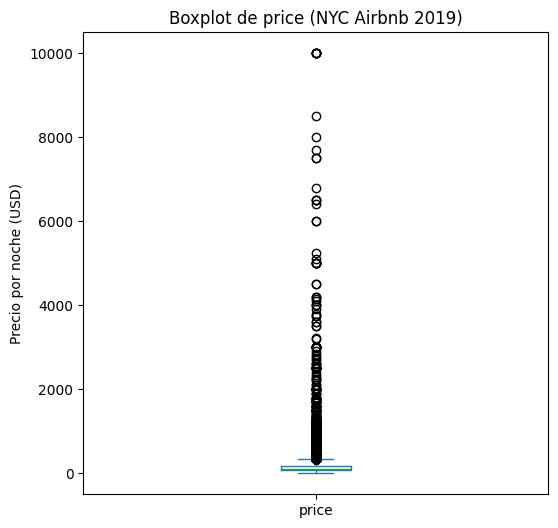

In [7]:
# 4.3 — Construye un boxplot de 'price' (con .plot(kind='box') o plt.boxplot()).

ax = df['price'].plot(kind='box', figsize=(6, 6))
ax.set_title('Boxplot de price (NYC Airbnb 2019)')
ax.set_ylabel('Precio por noche (USD)')
plt.show()

**4.4 — Conclusión (responde aquí en Markdown):**

Describe lo que observas en el histograma y el boxplot de `price`. ¿Los outliers son visibles en ambos gráficos? ¿En cuál se distinguen mejor? Relaciona tu respuesta con los valores de asimetría y curtosis que calculaste en la Actividad 3.

_Tu respuesta:_

En el histograma, casi todas las barras quedan comprimidas contra el extremo izquierdo del gráfico (precios bajos), y el resto del eje x, hasta llegar a \$10,000, aparece prácticamente vacío — apenas se alcanzan a distinguir unas barras diminutas dispersas muy a la derecha. Esto es exactamente lo que anticipa una asimetría de ~19.1: la inmensa mayoría de los anuncios se concentra en un rango de precios angosto, con una cola derecha tan larga que el histograma "se aplana" visualmente y dificulta ver el detalle de la distribución típica.

En el boxplot, los outliers sí son visibles, y de manera mucho más clara que en el histograma: aparecen como una gran cantidad de puntos individuales por encima del bigote superior, mientras que la caja central (que representa el IQR, de \$69 a \$175, calculado en la Actividad 2) se ve muy comprimida cerca de la parte baja del gráfico en comparación con la altura total del eje y (que tiene que llegar hasta \$10,000 para incluir el máximo).

En conclusión, el boxplot distingue mejor los outliers que el histograma para este caso: el histograma sí revela que hay algo raro (barras vacías, distribución aplastada a la izquierda) pero no señala individualmente cada valor atípico, mientras que el boxplot los marca explícitamente como puntos separados del bigote. Esto conecta directamente con la curtosis tan alta (~585.7) que calculamos: una curtosis extremadamente alta significa una alta concentración de datos cerca del centro combinada con colas muy pesadas y alargadas — justo el patrón de "caja comprimida + muchos puntos atípicos alejados" que se observa en el boxplot.

---
## Reflexión final (10 pts)

Con base en las 4 actividades anteriores: si tuvieras que explicarle a alguien que no ha visto este dataset por qué el precio "promedio" de \$152.72 puede ser engañoso, ¿qué le dirías, usando al menos dos de las medidas que calculaste?

_Tu respuesta:_

Le diría que el precio "promedio" de \$152.72 no describe bien lo que paga un huésped típico en un Airbnb de Nueva York, y que hay dos números que lo demuestran con evidencia concreta. Primero, la **mediana** es de solo \$106 — es decir, la mitad de los más de 48,000 anuncios cuestan \$106 o menos por noche, casi \$47 por debajo del promedio; esa brecha existe porque la media, a diferencia de la mediana, sí se deja arrastrar por los valores extremadamente altos. Segundo, el **IQR** (rango intercuartílico) confirma justo eso: el 50% central de los precios va de \$69 a \$175, un rango razonable y consistente con lo que cualquiera esperaría pagar — mientras que el precio máximo del dataset llega a \$10,000 por noche, un valor que por sí solo puede inflar el promedio de todo el conjunto sin representar a nadie más.

En resumen: si alguien va a usar "\$152.72" para estimar cuánto le costaría hospedarse en Nueva York, le convendría más fijarse en la mediana (\$106) o en el rango del IQR (\$69-\$175), porque esos números sí describen lo que paga la mayoría, mientras que el promedio está distorsionado por un puñado de anuncios extremadamente caros que jalan la cifra hacia arriba.

---
## Rúbrica de evaluación

| Actividad | Puntos | Criterio |
|---|---|---|
| 1. Tendencia central | 20 | Calcula correctamente media, mediana, moda; la conclusión (1.2) conecta la divergencia con la presencia de outliers, no es una afirmación aislada |
| 2. Dispersión | 20 | Calcula correctamente rango, varianza, std, IQR; la conclusión (2.2) justifica cuál medida es más representativa con evidencia del propio cálculo |
| 3. Forma | 20 | Calcula correctamente asimetría y curtosis; la conclusión (3.2) compara explícitamente contra el caso de `Income` visto en clase |
| 4. Visualización | 30 | Histograma y boxplot correctamente construidos (ambas versiones: `.plot()` y `plt.`); código comentado justificando decisiones (ej. bins); la conclusión (4.4) conecta lo visual con los estadísticos de la Actividad 3 |
| Reflexión final | 10 | La explicación usa al menos dos medidas concretas, no es una respuesta genérica |
| **Total** | **100** | |